[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/Estatistica/blob/main/02_probabilidade.ipynb)

# Estatística

## Engenharia de Produção

Prof. Diogo Ferreira de Lima Silva

Este notebook acompanha os tópicos da aula 2:

- espaço amostral e eventos;
- probabilidade clássica;
- interpretação frequentista;
- interpretação bayesiana;
- métodos de contagem;
- probabilidade condicional e Regra de Bayes.

## 1. Importações

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

## Espaço amostral e eventos

In [2]:
#Trabalhando com  Criando conjuntos em python

S = {1, 2, 3, 4, 5, 6}
A = {1, 3, 5}
B = {4, 6}
C = {4, 5, 6}
D = {2}

print("S =", S)
print("A =", A)
print("B =", B)
print("C =", C)
print("D =", D)
print("A união B =", A.union(B))
print("A interseção C =", A.intersection(C))
print("Complemento de A =", S.difference(A))

S = {1, 2, 3, 4, 5, 6}
A = {1, 3, 5}
B = {4, 6}
C = {4, 5, 6}
D = {2}
A união B = {1, 3, 4, 5, 6}
A interseção C = {5}
Complemento de A = {2, 4, 6}


##Probabilidade clássica — dois dados

In [7]:
# Espaço amostral: todos os pares possíveis (dado1, dado2)

# product gera o produto cartesiano
espaco = list(itertools.product(range(1, 7), repeat=2))

print("Espaço amostral =", espaco)


# Vamos listar quais eventos somam 7
favoraveis = [par for par in espaco if sum(par) == 7]
print("Pares favoráveis =", favoraveis)


# Vamos imprimir na tela os tamanhos das duas listas
print("Casos possíveis =", len(espaco))
print("Casos favoráveis =", len(favoraveis))


# Probabilidade clássica = casos favoráveis / casos possíveis
print("Probabilidade =", len(favoraveis) / len(espaco))

Espaço amostral = [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
Pares favoráveis = [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
Casos possíveis = 36
Casos favoráveis = 6
Probabilidade = 0.16666666666666666


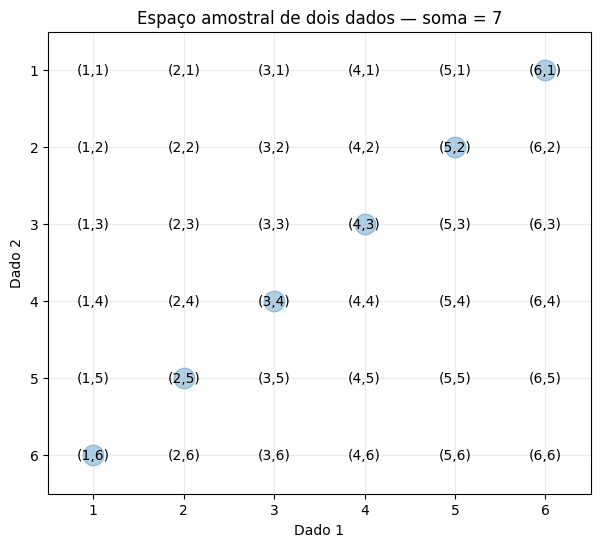

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
for x, y in espaco:
    ax.text(x, y, f"({x},{y})", ha="center", va="center", fontsize=10)

xs = [x for x, y in favoraveis]
ys = [y for x, y in favoraveis]
ax.scatter(xs, ys, s=220, alpha=0.35)

ax.set_xlim(0.5, 6.5)
ax.set_ylim(0.5, 6.5)
ax.set_xticks(range(1, 7))
ax.set_yticks(range(1, 7))
ax.set_xlabel("Dado 1")
ax.set_ylabel("Dado 2")
ax.set_title("Espaço amostral de dois dados — soma = 7")
ax.grid(True, alpha=0.25)
plt.gca().invert_yaxis()
plt.show()

### Interpretação frequentista

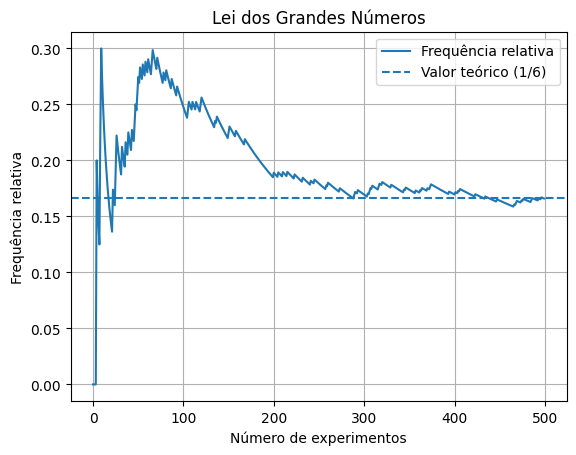

In [9]:
np.random.seed(42)  # garante reprodutibilidade

n = 500  # número de experimentos

# Simulando lançamentos de dois dados
dado1 = np.random.randint(1, 7, n)
dado2 = np.random.randint(1, 7, n)

# Soma dos resultados
somas = dado1 + dado2

# Indicador do evento: soma == 7
evento = (somas == 7).astype(int)

# Frequência relativa acumulada
frequencia_relativa = np.cumsum(evento) / np.arange(1, n + 1)

# Valor teórico
valor_teorico = 1 / 6

# Gráfico
plt.plot(frequencia_relativa, label="Frequência relativa")
plt.axhline(valor_teorico, linestyle="--", label="Valor teórico (1/6)")

plt.xlabel("Número de experimentos")
plt.ylabel("Frequência relativa")
plt.title("Lei dos Grandes Números")
plt.legend()
plt.grid()
plt.show()

##Métodos de contagem

In [10]:
# 1) Ordenado + com reposição
def ordenado_com_reposicao(n, r):
    # Exemplo: senha de 4 dígitos (0–9)
    return n ** r

# 2) Ordenado + sem reposição (arranjos)
def arranjos(n, r):
    # Exemplo: pódio
    return math.factorial(n) // math.factorial(n - r)

# 3) Não ordenado + sem reposição (combinações)
def combinacoes(n, r):
    # Exemplo: escolher alunos
    return math.comb(n, r)

# 4) Não ordenado + com reposição
def combinacoes_com_reposicao(n, r):
    # Exemplo: bolas de sorvete
    return math.comb(n + r - 1, r)


print("Senha (10^4):", ordenado_com_reposicao(10, 4))
print("Pódio:", arranjos(10, 3))
print("Grupo de alunos:", combinacoes(10, 3))
print("Sorvetes:", combinacoes_com_reposicao(5, 3))

Senha (10^4): 10000
Pódio: 720
Grupo de alunos: 120
Sorvetes: 35


##Exemplo com cartas

In [11]:
prob_contagem = 1 / math.comb(52, 4)

print("Probabilidade por contagem =", prob_contagem)


Probabilidade por contagem = 3.6937852063902484e-06


## Regra de Bayes — Triagem médica

In [14]:
# Probabilidades dadas
P_D = 0.01          # prevalência
P_notD = 1 - P_D

P_pos_dado_D = 0.90
P_pos_dado_notD = 0.02

# Probabilidade total de teste positivo
P_pos = P_pos_dado_D * P_D + P_pos_dado_notD * P_notD

# Regra de Bayes
P_D_dado_pos = (P_pos_dado_D * P_D) / P_pos

print("P(+) =", P_pos)
print("P(D | +) =", P_D_dado_pos)
print("Em % =", 100 * P_D_dado_pos)

P(+) = 0.028800000000000003
P(D | +) = 0.3125
Em % = 31.25


In [15]:
# População hipotética
N = 10000

doentes = int(N * P_D)
saudaveis = N - doentes

# Aplicando o teste
verdadeiros_positivos = int(doentes * P_pos_dado_D)
falsos_positivos = int(saudaveis * P_pos_dado_notD)

total_positivos = verdadeiros_positivos + falsos_positivos

print("Doentes:", doentes)
print("Saudáveis:", saudaveis)
print("Verdadeiros positivos:", verdadeiros_positivos)
print("Falsos positivos:", falsos_positivos)

print("P(D|+) ≈", verdadeiros_positivos / total_positivos)

Doentes: 100
Saudáveis: 9900
Verdadeiros positivos: 90
Falsos positivos: 198
P(D|+) ≈ 0.3125


##Efeito da probabilidade a priori

In [16]:
P_D2 = 0.10
P_notD2 = 1 - P_D2
P_pos2 = P_pos_dado_D * P_D2 + P_pos_dado_notD * P_notD2
P_D_dado_pos2 = (P_pos_dado_D * P_D2) / P_pos2

print("Nova P(D) =", P_D2)
print("Nova P(D|+) =", P_D_dado_pos2)
print("Nova P(D|+) em % =", 100 * P_D_dado_pos2)

Nova P(D) = 0.1
Nova P(D|+) = 0.8333333333333334
Nova P(D|+) em % = 83.33333333333334


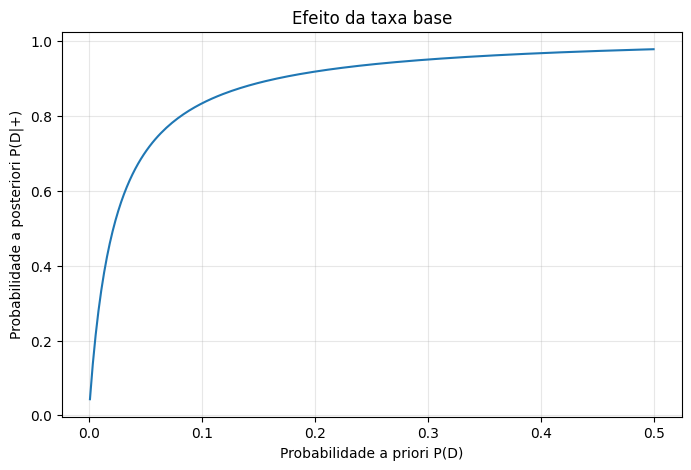

In [17]:
priors = np.linspace(0.001, 0.5, 200)
posteriors = (P_pos_dado_D * priors) / (P_pos_dado_D * priors + P_pos_dado_notD * (1 - priors))

plt.figure(figsize=(8, 5))
plt.plot(priors, posteriors)
plt.xlabel("Probabilidade a priori P(D)")
plt.ylabel("Probabilidade a posteriori P(D|+)")
plt.title("Efeito da taxa base")
plt.grid(True, alpha=0.3)
plt.show()

##Regra de Bayes — Controle de qualidade

In [18]:
# Probabilidades a priori
P_A1, P_A2, P_A3 = 0.50, 0.30, 0.20

# Taxas de defeito
P_D_A1 = 0.02
P_D_A2 = 0.05
P_D_A3 = 0.10

# Probabilidade total de defeito
P_D = (
    P_D_A1 * P_A1 +
    P_D_A2 * P_A2 +
    P_D_A3 * P_A3
)

# Aplicando Bayes
P_A3_dado_D = (P_D_A3 * P_A3) / P_D

print("P(D) =", P_D)
print("P(A3 | D) =", P_A3_dado_D)

P(D) = 0.045000000000000005
P(A3 | D) = 0.4444444444444445


In [21]:
# Qual máquina é mais crítica?

posteriores = {
    "A1": (P_D_A1 * P_A1) / P_D,
    "A2": (P_D_A2 * P_A2) / P_D,
    "A3": (P_D_A3 * P_A3) / P_D,
}

print(posteriores)
print("Máquina mais provável dado defeito:", max(posteriores, key=posteriores.get))

{'A1': 0.2222222222222222, 'A2': 0.33333333333333326, 'A3': 0.4444444444444445}
Máquina mais provável dado defeito: A3
